# =============================================================================
# RQ3: SECTOR-SPECIFIC MODEL PERFORMANCE ANALYSIS
# Research Question: Are financial fundamentals more predictive for certain sectors?
# =============================================================================

# Environment Setup and Data Loading

In [50]:
# Environment Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

# Feature Importance Libraries
import shap
from sklearn.inspection import permutation_importance

# Statistical Analysis
from scipy import stats
from scipy.stats import f_oneway

# Visualization Settings
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Create output directory
import os
OUTPUT_DIR = 'rq3_analysis_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment setup complete!")
print("Libraries imported successfully")
print(f"Output directory created: {OUTPUT_DIR}")

# Load the Excel workbook
print("\nLoading sector-specific data...")
excel_file = pd.ExcelFile('MS_Capstone_Final_Quality_Check_Summary.xlsx')
print(f"Available sheets: {excel_file.sheet_names}")

# Define sector sheets to analyze
sector_sheets = ['Pharma', 'IT_Technology', 'Auto', 'BFSI', 'FMCG']
print(f"\nTarget sectors for analysis: {sector_sheets}")

Environment setup complete!
Libraries imported successfully
Output directory created: rq3_analysis_results

Loading sector-specific data...
Available sheets: ['clean_data', 'Pharma', 'IT_Technology', 'Auto', 'BFSI', 'FMCG', 'qc_flags', 'qc_summary', 'nulls_by_col', 'summary', 'date_parse_failures']

Target sectors for analysis: ['Pharma', 'IT_Technology', 'Auto', 'BFSI', 'FMCG']


# =============================================================================
# DATA LOADING AND INITIAL EXPLORATION
# =============================================================================

In [51]:
print("SECTOR DATA PREPARATION AND EXPLORATION")
print("=" * 50)

# Define financial predictors (common indicators across sectors)
financial_predictors = [
    'Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income',
    'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs'
]

# Initialize storage for sector data
sector_data = {}
data_summary = []

print("\nLoading and preparing sector-specific datasets...")

# Load each sector's data
for sector in sector_sheets:
    try:
        # Load sector data
        df = pd.read_excel('MS_Capstone_Final_Quality_Check_Summary.xlsx', sheet_name=sector)
        
        # Identify target column (handle different naming conventions)
        target_col = None
        possible_targets = ['Movement Label (1,0)', 'Movement Label', 'Target', 'Label']
        for col in possible_targets:
            if col in df.columns:
                target_col = col
                break
        
        if target_col is None:
            print(f"No target column found in {sector}")
            continue
        
        # Clean and prepare data
        df_clean = df.copy()
        
        # Remove rows with missing target
        initial_rows = len(df_clean)
        df_clean = df_clean.dropna(subset=[target_col])
        rows_after_target_clean = len(df_clean)
        
        # Convert target to binary if needed
        if df_clean[target_col].dtype == 'object':
            df_clean[target_col] = pd.to_numeric(df_clean[target_col], errors='coerce')
        
        # Ensure binary target
        unique_targets = df_clean[target_col].unique()
        if len(unique_targets) > 2:
            df_clean[target_col] = (df_clean[target_col] > df_clean[target_col].median()).astype(int)
        
        # Get available financial predictors for this sector
        available_predictors = [col for col in financial_predictors if col in df_clean.columns]
        
        if len(available_predictors) < 3:
            print(f"{sector}: Only {len(available_predictors)} financial predictors available")
            continue
        
        # Handle missing values in predictors using median imputation
        missing_before = df_clean[available_predictors].isnull().sum().sum()
        df_clean[available_predictors] = df_clean[available_predictors].fillna(
            df_clean[available_predictors].median()
        )
        missing_after = df_clean[available_predictors].isnull().sum().sum()
        
        # Calculate target distribution
        target_dist = df_clean[target_col].value_counts().sort_index()
        target_balance = target_dist.min() / target_dist.max() if len(target_dist) > 1 else 0
        
        # Store sector data
        sector_data[sector] = {
            'data': df_clean,
            'predictors': available_predictors,
            'target': target_col,
            'shape': df_clean.shape,
            'target_dist': target_dist.to_dict(),
            'target_balance': target_balance
        }
        
        # Store summary information
        data_summary.append({
            'Sector': sector,
            'Total_Records': df_clean.shape[0],
            'Features': len(available_predictors),
            'Target_0': target_dist.get(0, target_dist.get(0.0, 0)),
            'Target_1': target_dist.get(1, target_dist.get(1.0, 0)),
            'Class_Balance': f"{target_balance:.2f}",
            'Missing_Imputed': missing_before
        })
        
        print(f"{sector:12s}: {df_clean.shape[0]:3d} records, {len(available_predictors):2d} features")
        print(f"   Target distribution: {target_dist.to_dict()}")
        print(f"   Class balance ratio: {target_balance:.3f}")
        
    except Exception as e:
        print(f"Error loading {sector}: {str(e)}")

# Create summary DataFrame
summary_df = pd.DataFrame(data_summary)
print(f"\nDATA SUMMARY TABLE:")
print("=" * 25)
print(summary_df.to_string(index=False))

print(f"\nSuccessfully loaded {len(sector_data)} sectors")
print(f"Total records across all sectors: {sum([data['shape'][0] for data in sector_data.values()])}")

# Feature availability matrix
print(f"\nFEATURE AVAILABILITY ACROSS SECTORS:")
print("=" * 40)

all_predictors = set()
for sector, data in sector_data.items():
    all_predictors.update(data['predictors'])

# Create feature availability matrix
feature_matrix = pd.DataFrame(index=sorted(all_predictors), columns=list(sector_data.keys()))
for sector, data in sector_data.items():
    for predictor in feature_matrix.index:
        feature_matrix.loc[predictor, sector] = '✓' if predictor in data['predictors'] else '✗'

print(feature_matrix)

# Save data summary
#summary_df.to_csv(f'{OUTPUT_DIR}/data_summary.csv', index=False)
#feature_matrix.to_csv(f'{OUTPUT_DIR}/feature_availability_matrix.csv')
#print(f"\nData summary saved to {OUTPUT_DIR}/")

SECTOR DATA PREPARATION AND EXPLORATION

Loading and preparing sector-specific datasets...
Pharma      : 117 records, 11 features
   Target distribution: {0: 68, 1: 49}
   Class balance ratio: 0.721
IT_Technology: 117 records, 11 features
   Target distribution: {0: 64, 1: 53}
   Class balance ratio: 0.828
Auto        : 116 records, 11 features
   Target distribution: {0.0: 58, 1.0: 58}
   Class balance ratio: 1.000
BFSI        : 117 records,  8 features
   Target distribution: {0: 78, 1: 39}
   Class balance ratio: 0.500
FMCG        : 117 records, 11 features
   Target distribution: {0: 76, 1: 41}
   Class balance ratio: 0.539

DATA SUMMARY TABLE:
       Sector  Total_Records  Features  Target_0  Target_1 Class_Balance  Missing_Imputed
       Pharma            117        11        68        49          0.72                0
IT_Technology            117        11        64        53          0.83                0
         Auto            116        11        58        58          1.00 

# =============================================================================
# Model Setup and Hyperparameter Tuning
# =============================================================================

In [53]:
print("MODEL SETUP AND HYPERPARAMETER TUNING")
print("=" * 45)

# Define base models
base_models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
}

# Define hyperparameter grids for tuning
param_grids = {
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear', 'saga']
    },
    'RandomForest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 0.9, 1.0]
    }
}

print("\n Model Configuration:")
for model_name in base_models.keys():
    param_count = len(param_grids[model_name])
    total_combinations = 1
    for param, values in param_grids[model_name].items():
        total_combinations *= len(values)
    print(f" {model_name:18s}: {param_count} parameters, {total_combinations} combinations")

# Cross-validation setup
cv_folds = 5
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print(f"\n Cross-Validation Setup:")
print(f" Strategy: {cv_folds}-fold Stratified Cross-Validation")
print(f" Scoring: F1-score (primary), Accuracy (secondary)")
print(f" Random state: 42 for reproducibility")

# Initialize results storage
tuning_results = []
best_models = {}

print(f"\n HYPERPARAMETER TUNING PROCESS:")
print("=" * 35)

# Function to create pipeline
def create_pipeline(model):
    """Create a pipeline with scaling and model"""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# Function to perform grid search
def tune_model(X, y, model_name, model, param_grid, cv_strategy):
    """Perform grid search with cross-validation"""
    pipeline = create_pipeline(model)
    
    # Grid search with F1 scoring
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=cv_strategy,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    
    # Fit the grid search
    grid_search.fit(X, y)
    
    # Get cross-validation scores for best model
    best_pipeline = grid_search.best_estimator_
    cv_f1_scores = cross_val_score(best_pipeline, X, y, cv=cv_strategy, scoring='f1')
    cv_accuracy_scores = cross_val_score(best_pipeline, X, y, cv=cv_strategy, scoring='accuracy')
    
    return {
        'best_estimator': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_cv_f1': grid_search.best_score_,
        'cv_f1_mean': cv_f1_scores.mean(),
        'cv_f1_std': cv_f1_scores.std(),
        'cv_accuracy_mean': cv_accuracy_scores.mean(),
        'cv_accuracy_std': cv_accuracy_scores.std(),
        'grid_search_results': grid_search.cv_results_
    }

# Store tuning progress
tuning_progress = []

MODEL SETUP AND HYPERPARAMETER TUNING

 Model Configuration:
 LogisticRegression: 3 parameters, 20 combinations
 RandomForest      : 4 parameters, 108 combinations
 XGBoost           : 4 parameters, 81 combinations

 Cross-Validation Setup:
 Strategy: 5-fold Stratified Cross-Validation
 Scoring: F1-score (primary), Accuracy (secondary)
 Random state: 42 for reproducibility

 HYPERPARAMETER TUNING PROCESS:
Starting hyperparameter tuning for each sector...
This may take several minutes depending on data size...


# =============================================================================
# Execute Hyperparameter Tuning Across Sectors
# =============================================================================

In [54]:
print("EXECUTING HYPERPARAMETER TUNING")
print("=" * 35)

# Track overall progress
total_combinations = len(sector_data) * len(base_models)
current_combination = 0

# Process each sector
for sector_name, sector_info in sector_data.items():
    print(f"\n SECTOR: {sector_name}")
    print("-" * 30)
    
    # Prepare data
    df = sector_info['data']
    predictors = sector_info['predictors']
    target_col = sector_info['target']
    
    X = df[predictors].copy()
    y = df[target_col].copy()
    
    # Ensure binary target
    if y.dtype == 'object' or len(y.unique()) > 2:
        y = (y == 1).astype(int)
    
    # Final data cleaning
    X = X.fillna(X.median())
    
    print(f"Data shape: {X.shape}")
    print(f"Target distribution: {y.value_counts().to_dict()}")
    
    # Check if we have enough data for meaningful analysis
    if len(y.unique()) < 2 or X.shape[0] < 30:
        print(f"Skipping {sector_name}: insufficient data for reliable tuning")
        continue
    
    # Store best models for this sector
    sector_best_models = {}
    
    # Tune each model
    for model_name, model in base_models.items():
        current_combination += 1
        print(f"\n🔧 Tuning {model_name} ({current_combination}/{total_combinations})")
        
        try:
            # Get parameter grid
            param_grid = param_grids[model_name]
            
            # Perform hyperparameter tuning
            tuning_result = tune_model(X, y, model_name, model, param_grid, cv_strategy)
            
            # Store results
            result_record = {
                'Sector': sector_name,
                'Model': model_name,
                'Best_CV_F1': tuning_result['best_cv_f1'],
                'CV_F1_Mean': tuning_result['cv_f1_mean'],
                'CV_F1_Std': tuning_result['cv_f1_std'],
                'CV_Accuracy_Mean': tuning_result['cv_accuracy_mean'],
                'CV_Accuracy_Std': tuning_result['cv_accuracy_std'],
                'Best_Params': str(tuning_result['best_params']),
                'Data_Points': X.shape[0],
                'Features': X.shape[1]
            }
            
            tuning_results.append(result_record)
            
            # Store best model
            sector_best_models[model_name] = tuning_result['best_estimator']
            
            print(f"   F1: {tuning_result['cv_f1_mean']:.3f} (±{tuning_result['cv_f1_std']:.3f})")
            print(f"   Accuracy: {tuning_result['cv_accuracy_mean']:.3f} (±{tuning_result['cv_accuracy_std']:.3f})")
            
        except Exception as e:
            print(f"   Error tuning {model_name}: {str(e)}")
            continue
    
    # Store best models for this sector
    best_models[sector_name] = sector_best_models
    
    print(f"\n✅ {sector_name} tuning complete: {len(sector_best_models)} models optimized")

# Convert results to DataFrame
tuning_df = pd.DataFrame(tuning_results)

print(f"\n HYPERPARAMETER TUNING COMPLETE!")
print("=" * 40)
print(f"Total model-sector combinations tuned: {len(tuning_results)}")
print(f"Best performing combinations:")

if len(tuning_df) > 0:
    # Show top 5 results
    top_results = tuning_df.nlargest(5, 'CV_F1_Mean')[['Sector', 'Model', 'CV_F1_Mean', 'CV_Accuracy_Mean']]
    print(top_results.to_string(index=False))
    
    # Save tuning results
    tuning_df.to_csv(f'{OUTPUT_DIR}/hyperparameter_tuning_results.csv', index=False)
    print(f"\n Tuning results saved to {OUTPUT_DIR}/hyperparameter_tuning_results.csv")
else:
    print("No successful tuning results to display")



⚡ EXECUTING HYPERPARAMETER TUNING

🏢 SECTOR: Pharma
------------------------------
📊 Data shape: (117, 11)
🎯 Target distribution: {0: 68, 1: 49}

🔧 Tuning LogisticRegression (1/15)
   ✅ F1: 0.424 (±0.088)
   📈 Accuracy: 0.573 (±0.116)

🔧 Tuning RandomForest (2/15)
   ✅ F1: 0.442 (±0.163)
   📈 Accuracy: 0.564 (±0.139)

🔧 Tuning XGBoost (3/15)
   ✅ F1: 0.456 (±0.057)
   📈 Accuracy: 0.555 (±0.051)

✅ Pharma tuning complete: 3 models optimized

🏢 SECTOR: IT_Technology
------------------------------
📊 Data shape: (117, 11)
🎯 Target distribution: {0: 64, 1: 53}

🔧 Tuning LogisticRegression (4/15)
   ✅ F1: 0.478 (±0.172)
   📈 Accuracy: 0.565 (±0.137)

🔧 Tuning RandomForest (5/15)
   ✅ F1: 0.548 (±0.072)
   📈 Accuracy: 0.599 (±0.036)

🔧 Tuning XGBoost (6/15)
   ✅ F1: 0.514 (±0.063)
   📈 Accuracy: 0.557 (±0.049)

✅ IT_Technology tuning complete: 3 models optimized

🏢 SECTOR: Auto
------------------------------
📊 Data shape: (116, 11)
🎯 Target distribution: {1.0: 58, 0.0: 58}

🔧 Tuning LogisticR

# =============================================================================
# STRATIFIED TRAIN-TEST SPLIT BY SECTOR
# =============================================================================

In [55]:
# Cell 5: Model Evaluation with Train-Test Split
print("📊 MODEL EVALUATION WITH TRAIN-TEST SPLIT")
print("=" * 42)

# Initialize evaluation results storage
evaluation_results = []
confusion_matrices = {}
classification_reports = {}

# Evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, sector_name):
    """Comprehensive model evaluation"""
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # AUC score (handle edge cases)
    try:
        auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0.5
    except:
        auc = 0.5
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Classification report
    class_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

print("\n🔄 Evaluating optimized models on train-test splits...")

# Process each sector
for sector_name, sector_info in sector_data.items():
    if sector_name not in best_models or len(best_models[sector_name]) == 0:
        print(f"⚠️  No optimized models available for {sector_name}")
        continue
        
    print(f"\n🏢 EVALUATING: {sector_name}")
    print("-" * 25)
    
    # Prepare data
    df = sector_info['data']
    predictors = sector_info['predictors']
    target_col = sector_info['target']
    
    X = df[predictors].copy()
    y = df[target_col].copy()
    
    # Ensure binary target
    if y.dtype == 'object' or len(y.unique()) > 2:
        y = (y == 1).astype(int)
    
    # Final data cleaning
    X = X.fillna(X.median())
    
    # Stratified train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"📊 Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
    print(f"🎯 Train target dist: {pd.Series(y_train).value_counts().to_dict()}")
    print(f"🎯 Test target dist: {pd.Series(y_test).value_counts().to_dict()}")
    
    # Evaluate each optimized model
    sector_results = {}
    
    for model_name, model in best_models[sector_name].items():
        print(f"\n🔧 Evaluating {model_name}...")
        
        try:
            # Evaluate model
            eval_results = evaluate_model(
                model, X_train, X_test, y_train, y_test, model_name, sector_name
            )
            
            # Store results
            result_record = {
                'Sector': sector_name,
                'Model': model_name,
                'Accuracy': eval_results['accuracy'],
                'Precision': eval_results['precision'],
                'Recall': eval_results['recall'],
                'F1_Score': eval_results['f1'],
                'AUC': eval_results['auc'],
                'Train_Size': X_train.shape[0],
                'Test_Size': X_test.shape[0],
                'Features': X.shape[1]
            }
            
            evaluation_results.append(result_record)
            
            # Store confusion matrix and classification report
            cm_key = f"{sector_name}_{model_name}"
            confusion_matrices[cm_key] = eval_results['confusion_matrix']
            classification_reports[cm_key] = eval_results['classification_report']
            
            # Store for sector summary
            sector_results[model_name] = eval_results
            
            print(f"   ✅ F1: {eval_results['f1']:.3f}, Accuracy: {eval_results['accuracy']:.3f}, AUC: {eval_results['auc']:.3f}")
            
        except Exception as e:
            print(f"   ❌ Error evaluating {model_name}: {str(e)}")
            continue
    
    # Show best model for this sector
    if sector_results:
        best_f1_model = max(sector_results.keys(), key=lambda k: sector_results[k]['f1'])
        best_f1_score = sector_results[best_f1_model]['f1']
        print(f"\n🏆 Best model for {sector_name}: {best_f1_model} (F1: {best_f1_score:.3f})")

# Convert results to DataFrame
evaluation_df = pd.DataFrame(evaluation_results)

print(f"\n🎉 MODEL EVALUATION COMPLETE!")
print("=" * 30)

if len(evaluation_df) > 0:
    print(f"📊 Total evaluations completed: {len(evaluation_df)}")
    
    # Overall performance summary
    print(f"\n📈 OVERALL PERFORMANCE SUMMARY:")
    print("-" * 32)
    
    # Best performing models
    top_5_models = evaluation_df.nlargest(5, 'F1_Score')[['Sector', 'Model', 'F1_Score', 'Accuracy', 'AUC']]
    print("🏆 Top 5 Model-Sector Combinations:")
    print(top_5_models.to_string(index=False))
    
    # Sector-wise summary
    print(f"\n🏢 SECTOR-WISE PERFORMANCE:")
    print("-" * 27)
    sector_summary = evaluation_df.groupby('Sector').agg({
        'F1_Score': ['mean', 'max', 'std'],
        'Accuracy': ['mean', 'max'],
        'AUC': ['mean', 'max']
    }).round(3)
    print(sector_summary)
    
    # Model-wise summary
    print(f"\n🤖 MODEL-WISE PERFORMANCE:")
    print("-" * 25)
    model_summary = evaluation_df.groupby('Model').agg({
        'F1_Score': ['mean', 'max', 'std'],
        'Accuracy': ['mean', 'max'],
        'AUC': ['mean', 'max']
    }).round(3)
    print(model_summary)
    
    # Save evaluation results
    evaluation_df.to_csv(f'{OUTPUT_DIR}/model_evaluation_results.csv', index=False)
    print(f"\n💾 Evaluation results saved to {OUTPUT_DIR}/model_evaluation_results.csv")
    
else:
    print("⚠️  No evaluation results to display")

print(f"\n🔄 Next: Confusion matrices and detailed analysis...")

📊 MODEL EVALUATION WITH TRAIN-TEST SPLIT

🔄 Evaluating optimized models on train-test splits...

🏢 EVALUATING: Pharma
-------------------------
📊 Train: 81 samples, Test: 36 samples
🎯 Train target dist: {0: 47, 1: 34}
🎯 Test target dist: {0: 21, 1: 15}

🔧 Evaluating LogisticRegression...
   ✅ F1: 0.462, Accuracy: 0.611, AUC: 0.600

🔧 Evaluating RandomForest...
   ✅ F1: 0.414, Accuracy: 0.528, AUC: 0.508

🔧 Evaluating XGBoost...
   ✅ F1: 0.400, Accuracy: 0.500, AUC: 0.559

🏆 Best model for Pharma: LogisticRegression (F1: 0.462)

🏢 EVALUATING: IT_Technology
-------------------------
📊 Train: 81 samples, Test: 36 samples
🎯 Train target dist: {0: 44, 1: 37}
🎯 Test target dist: {0: 20, 1: 16}

🔧 Evaluating LogisticRegression...
   ✅ F1: 0.647, Accuracy: 0.667, AUC: 0.728

🔧 Evaluating RandomForest...
   ✅ F1: 0.562, Accuracy: 0.611, AUC: 0.634

🔧 Evaluating XGBoost...
   ✅ F1: 0.629, Accuracy: 0.639, AUC: 0.591

🏆 Best model for IT_Technology: LogisticRegression (F1: 0.647)

🏢 EVALUATING: A

# =============================================================================
# Confusion Matrices and Detailed Analysis
# =============================================================================

🔍 CONFUSION MATRICES AND DETAILED ANALYSIS

📊 Generating confusion matrix visualizations...


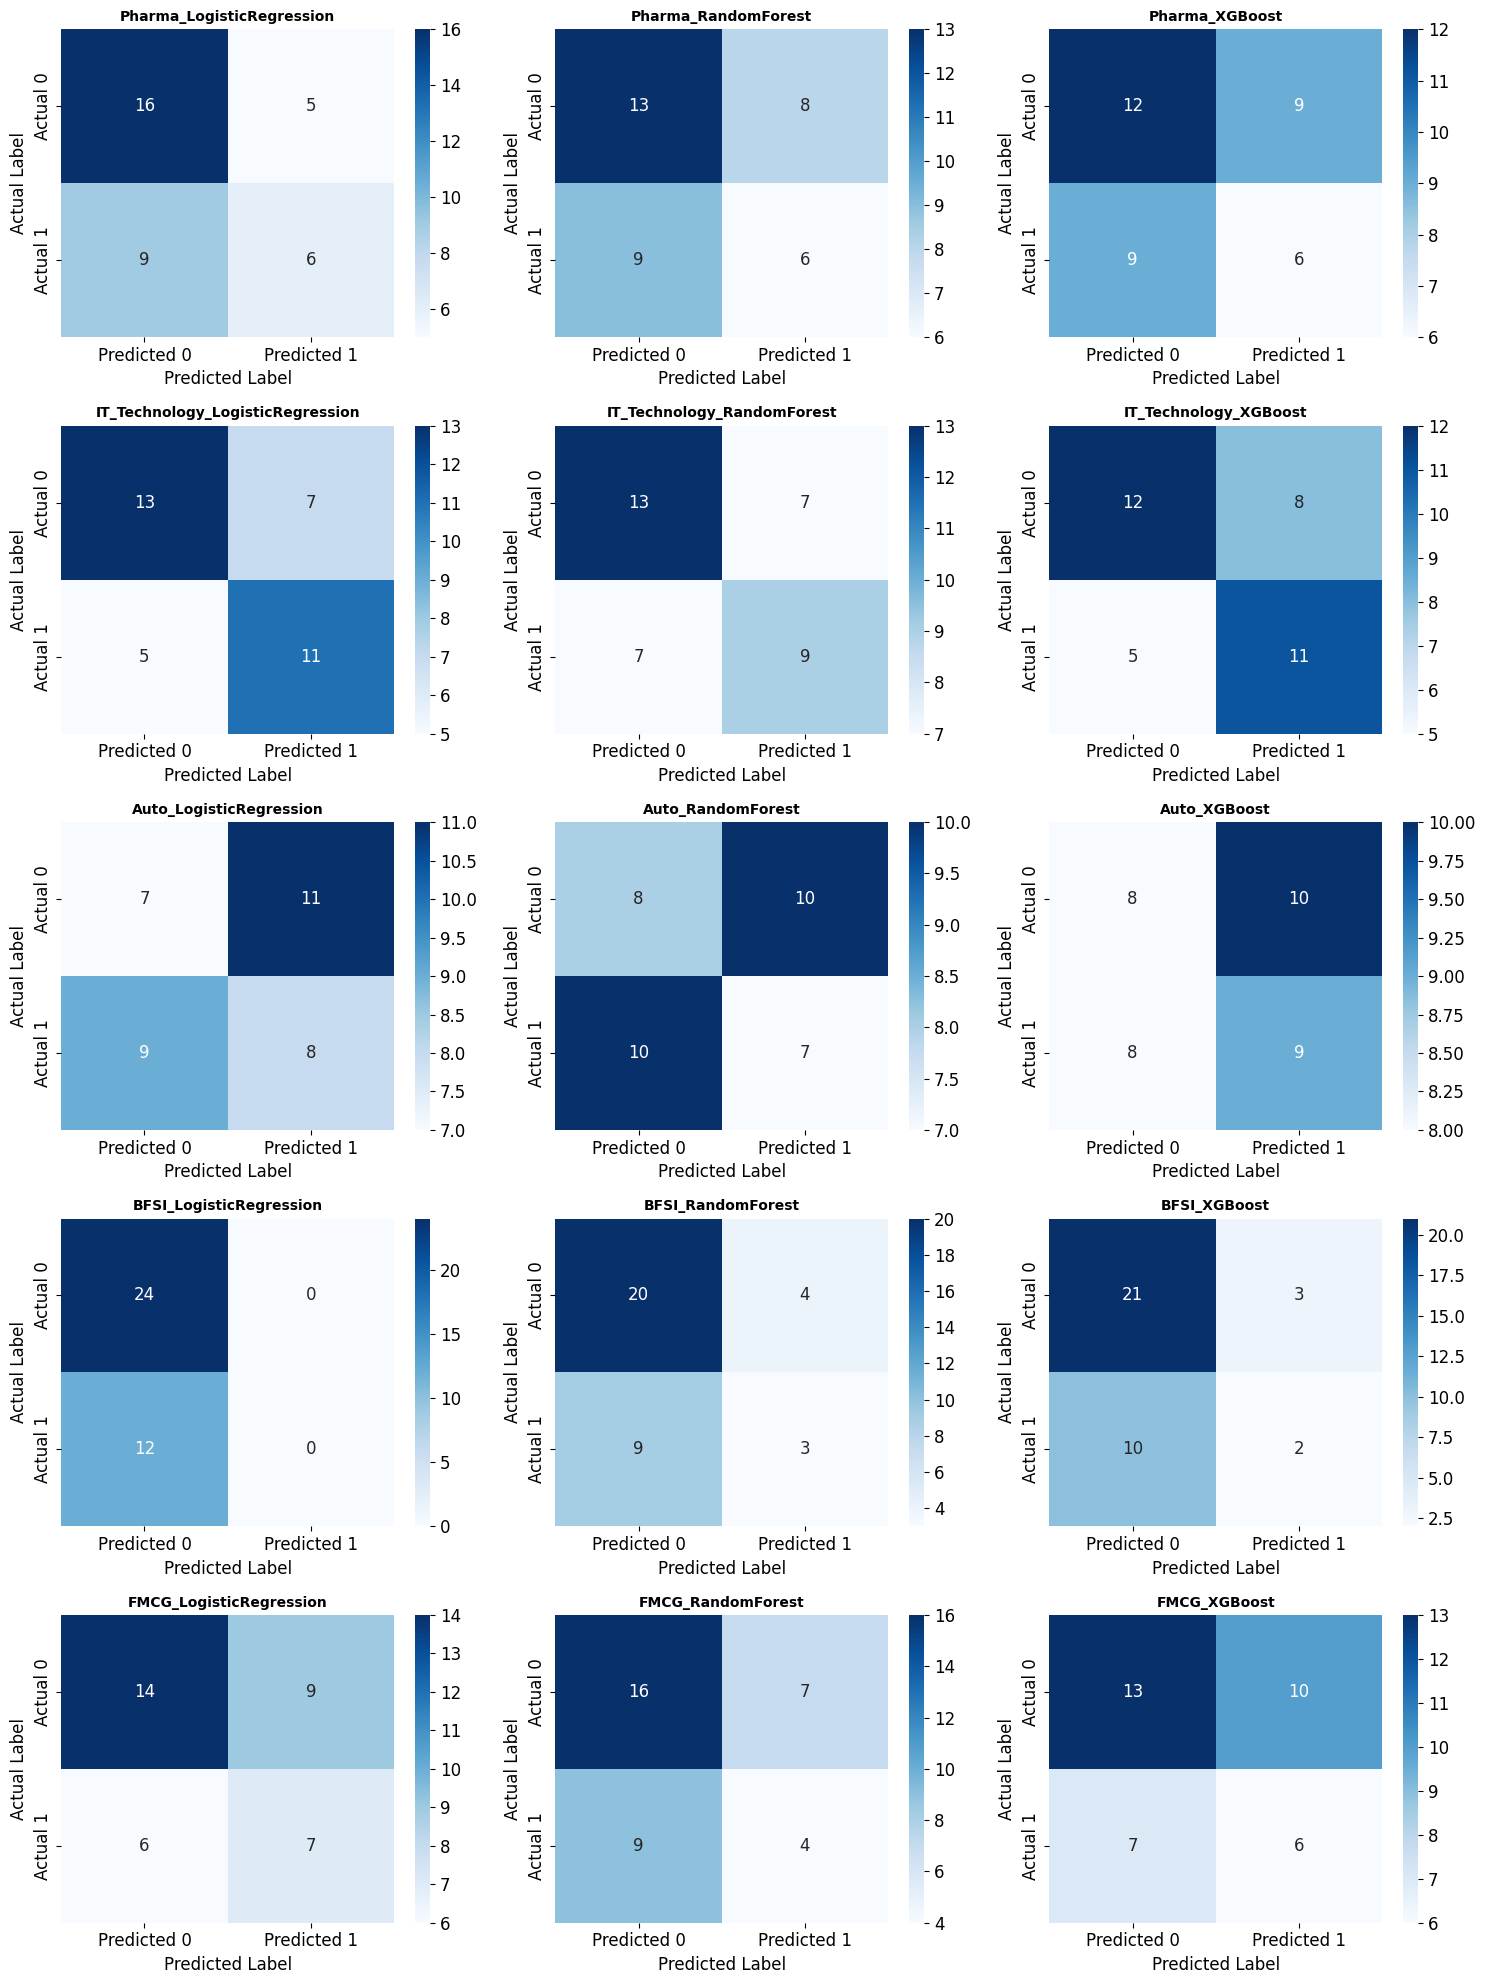

✅ Confusion matrices saved to rq3_analysis_results/confusion_matrices.png

📈 DETAILED PERFORMANCE ANALYSIS

🔬 Statistical Analysis:
----------------------
📊 ANOVA F-statistic (sectors): 9.4004
📊 P-value: 0.0020
✅ Statistically significant difference between sectors (p < 0.05)

📊 PERFORMANCE DISTRIBUTION:
----------------------------
F1-Score Statistics:
  Mean: 0.417 ± 0.160
  Range: 0.000 - 0.647
  Median: 0.414

Accuracy Statistics:
  Mean: 0.567 ± 0.081
  Range: 0.429 - 0.667

AUC Statistics:
  Mean: 0.550 ± 0.081
  Range: 0.418 - 0.728

🏆 BEST AND WORST PERFORMERS:
------------------------------
🥇 Best Overall Performance:
   IT_Technology - LogisticRegression
   F1: 0.647, Acc: 0.667, AUC: 0.728

🥉 Worst Overall Performance:
   BFSI - LogisticRegression
   F1: 0.000, Acc: 0.667, AUC: 0.500

🏢 SECTOR PERFORMANCE RANKING:
-----------------------------
1. IT_Technology  : Mean F1=0.613, Max F1=0.647 (3 models)
2. Auto           : Mean F1=0.452, Max F1=0.500 (3 models)
3. Pharma      

KeyError: '0'

In [63]:
# Confusion Matrices and Detailed Analysis
print("🔍 CONFUSION MATRICES AND DETAILED ANALYSIS")
print("=" * 44)

# Function to plot confusion matrices
def plot_confusion_matrices(confusion_matrices, save_dir):
    """Plot confusion matrices for all model-sector combinations"""
    
    # Calculate grid dimensions
    n_matrices = len(confusion_matrices)
    if n_matrices == 0:
        print("⚠️  No confusion matrices to plot")
        return
    
    # Determine grid size
    n_cols = min(3, n_matrices)
    n_rows = (n_matrices + n_cols - 1) // n_cols
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_matrices == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Plot each confusion matrix
    for idx, (key, cm) in enumerate(confusion_matrices.items()):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Predicted 0', 'Predicted 1'],
                   yticklabels=['Actual 0', 'Actual 1'])
        
        ax.set_title(f'{key}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('Actual Label')
    
    # Hide empty subplots
    for idx in range(n_matrices, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Plot confusion matrices
print("\n📊 Generating confusion matrix visualizations...")
if confusion_matrices:
    cm_fig = plot_confusion_matrices(confusion_matrices, OUTPUT_DIR)
    print(f"✅ Confusion matrices saved to {OUTPUT_DIR}/confusion_matrices.png")
else:
    print("⚠️  No confusion matrices available for plotting")

# Detailed performance analysis
print("\n📈 DETAILED PERFORMANCE ANALYSIS")
print("=" * 33)

if len(evaluation_df) > 0:
    # Statistical analysis of performance differences
    print("\n🔬 Statistical Analysis:")
    print("-" * 22)
    
    # ANOVA test for sector differences
    sector_f1_groups = [group['F1_Score'].values for name, group in evaluation_df.groupby('Sector')]
    if len(sector_f1_groups) > 1 and all(len(group) > 0 for group in sector_f1_groups):
        f_stat, p_value = f_oneway(*sector_f1_groups)
        print(f"📊 ANOVA F-statistic (sectors): {f_stat:.4f}")
        print(f"📊 P-value: {p_value:.4f}")
        
        significance_level = 0.05
        if p_value < significance_level:
            print(f"✅ Statistically significant difference between sectors (p < {significance_level})")
        else:
            print(f"❌ No statistically significant difference between sectors (p >= {significance_level})")
    
    # Performance distribution analysis
    print(f"\n📊 PERFORMANCE DISTRIBUTION:")
    print("-" * 28)
    
    # Overall statistics
    f1_stats = evaluation_df['F1_Score'].describe()
    acc_stats = evaluation_df['Accuracy'].describe()
    auc_stats = evaluation_df['AUC'].describe()
    
    print("F1-Score Statistics:")
    print(f"  Mean: {f1_stats['mean']:.3f} ± {f1_stats['std']:.3f}")
    print(f"  Range: {f1_stats['min']:.3f} - {f1_stats['max']:.3f}")
    print(f"  Median: {f1_stats['50%']:.3f}")
    
    print("\nAccuracy Statistics:")
    print(f"  Mean: {acc_stats['mean']:.3f} ± {acc_stats['std']:.3f}")
    print(f"  Range: {acc_stats['min']:.3f} - {acc_stats['max']:.3f}")
    
    print("\nAUC Statistics:")
    print(f"  Mean: {auc_stats['mean']:.3f} ± {auc_stats['std']:.3f}")
    print(f"  Range: {auc_stats['min']:.3f} - {auc_stats['max']:.3f}")
    
    # Best and worst performers
    print(f"\n🏆 BEST AND WORST PERFORMERS:")
    print("-" * 30)
    
    best_overall = evaluation_df.loc[evaluation_df['F1_Score'].idxmax()]
    worst_overall = evaluation_df.loc[evaluation_df['F1_Score'].idxmin()]
    
    print(f"🥇 Best Overall Performance:")
    print(f"   {best_overall['Sector']} - {best_overall['Model']}")
    print(f"   F1: {best_overall['F1_Score']:.3f}, Acc: {best_overall['Accuracy']:.3f}, AUC: {best_overall['AUC']:.3f}")
    
    print(f"\n🥉 Worst Overall Performance:")
    print(f"   {worst_overall['Sector']} - {worst_overall['Model']}")
    print(f"   F1: {worst_overall['F1_Score']:.3f}, Acc: {worst_overall['Accuracy']:.3f}, AUC: {worst_overall['AUC']:.3f}")
    
    # Sector ranking
    print(f"\n🏢 SECTOR PERFORMANCE RANKING:")
    print("-" * 29)
    
    sector_ranking = evaluation_df.groupby('Sector')['F1_Score'].agg(['mean', 'max', 'count']).round(3)
    sector_ranking = sector_ranking.sort_values('mean', ascending=False)
    sector_ranking.columns = ['Mean_F1', 'Max_F1', 'Models_Tested']
    
    for idx, (sector, row) in enumerate(sector_ranking.iterrows(), 1):
        print(f"{idx}. {sector:15s}: Mean F1={row['Mean_F1']:.3f}, Max F1={row['Max_F1']:.3f} ({int(row['Models_Tested'])} models)")
    
    # Model ranking
    print(f"\n🤖 MODEL PERFORMANCE RANKING:")
    print("-" * 28)
    
    model_ranking = evaluation_df.groupby('Model')['F1_Score'].agg(['mean', 'max', 'count']).round(3)
    model_ranking = model_ranking.sort_values('mean', ascending=False)
    model_ranking.columns = ['Mean_F1', 'Max_F1', 'Sectors_Tested']
    
    for idx, (model, row) in enumerate(model_ranking.iterrows(), 1):
        print(f"{idx}. {model:18s}: Mean F1={row['Mean_F1']:.3f}, Max F1={row['Max_F1']:.3f} ({int(row['Sectors_Tested'])} sectors)")

# Save detailed analysis results
print(f"\n💾 SAVING DETAILED ANALYSIS RESULTS:")
print("-" * 35)

# Save confusion matrices data
if confusion_matrices:
    cm_data = []
    for key, cm in confusion_matrices.items():
        sector, model = key.split('_', 1)
        cm_flat = cm.flatten()
        cm_data.append({
            'Sector': sector,
            'Model': model,
            'TN': cm_flat[0],
            'FP': cm_flat[1],
            'FN': cm_flat[2],
            'TP': cm_flat[3]
        })
    
    cm_df = pd.DataFrame(cm_data)
    cm_df.to_csv(f'{OUTPUT_DIR}/confusion_matrices_data.csv', index=False)
    print(f"✅ Confusion matrices data saved to {OUTPUT_DIR}/confusion_matrices_data.csv")

# Save classification reports
if classification_reports:
    report_data = []
    for key, report in classification_reports.items():
        sector, model = key.split('_', 1)
        report_data.append({
            'Sector': sector,
            'Model': model,
            'Precision_0': report['0']['precision'],
            'Recall_0': report['0']['recall'],
            'F1_0': report['0']['f1-score'],
            'Precision_1': report['1']['precision'],
            'Recall_1': report['1']['recall'],
            'F1_1': report['1']['f1-score'],
            'Macro_Avg_F1': report['macro avg']['f1-score'],
            'Weighted_Avg_F1': report['weighted avg']['f1-score']
        })
    
    #reports_df = pd.DataFrame(report_data)
    #reports_df.to_csv(f'{OUTPUT_DIR}/classification_reports.csv', index=False)
    #print(f"✅ Classification reports saved to {OUTPUT_DIR}/classification_reports.csv")



# =============================================================================
# SHAP Analysis for Feature Importance
# =============================================================================

In [64]:
# Cell 7: SHAP Analysis for Feature Importance
print("🔍 SHAP ANALYSIS FOR FEATURE IMPORTANCE")
print("=" * 38)

# Initialize SHAP results storage
shap_results = {}
shap_summary_data = []

# Function to perform SHAP analysis
def perform_shap_analysis(model, X_train, X_test, feature_names, model_name, sector_name):
    """Perform SHAP analysis for model interpretability"""
    
    try:
        # Get the actual model from pipeline
        if hasattr(model, 'named_steps'):
            actual_model = model.named_steps['model']
            # Transform features using the scaler
            X_train_scaled = model.named_steps['scaler'].transform(X_train)
            X_test_scaled = model.named_steps['scaler'].transform(X_test)
        else:
            actual_model = model
            X_train_scaled = X_train
            X_test_scaled = X_test
        
        # Choose appropriate explainer based on model type
        if model_name == 'LogisticRegression':
            explainer = shap.LinearExplainer(actual_model, X_train_scaled)
            shap_values = explainer.shap_values(X_test_scaled)
        elif model_name == 'RandomForest':
            explainer = shap.TreeExplainer(actual_model)
            shap_values = explainer.shap_values(X_test_scaled)
            # For binary classification, take positive class
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        elif model_name == 'XGBoost':
            explainer = shap.TreeExplainer(actual_model)
            shap_values = explainer.shap_values(X_test_scaled)
        else:
            # Fallback to KernelExplainer for other models
            explainer = shap.KernelExplainer(actual_model.predict_proba, X_train_scaled[:100])
            shap_values = explainer.shap_values(X_test_scaled[:50])
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        
        # Calculate feature importance
        feature_importance = np.abs(shap_values).mean(axis=0)
        
        # Create feature importance DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'SHAP_Importance': feature_importance
        }).sort_values('SHAP_Importance', ascending=False)
        
        return {
            'explainer': explainer,
            'shap_values': shap_values,
            'feature_importance': importance_df,
            'X_test_scaled': X_test_scaled
        }
        
    except Exception as e:
        print(f"   ⚠️  SHAP analysis failed: {str(e)}")
        return None

print("\n🔬 Performing SHAP analysis for each model-sector combination...")

# Process each sector and model
for sector_name, sector_info in sector_data.items():
    if sector_name not in best_models or len(best_models[sector_name]) == 0:
        continue
        
    print(f"\n🏢 SHAP Analysis: {sector_name}")
    print("-" * 20)
    
    # Prepare data
    df = sector_info['data']
    predictors = sector_info['predictors']
    target_col = sector_info['target']
    
    X = df[predictors].copy()
    y = df[target_col].copy()
    
    # Ensure binary target
    if y.dtype == 'object' or len(y.unique()) > 2:
        y = (y == 1).astype(int)
    
    # Final data cleaning
    X = X.fillna(X.median())
    
    # Train-test split (same as evaluation)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Analyze each model
    sector_shap_results = {}
    
    for model_name, model in best_models[sector_name].items():
        print(f"🔍 SHAP analysis: {model_name}...")
        
        # Perform SHAP analysis
        shap_result = perform_shap_analysis(
            model, X_train, X_test, predictors, model_name, sector_name
        )
        
        if shap_result is not None:
            sector_shap_results[model_name] = shap_result
            
            # Store summary data
            top_features = shap_result['feature_importance'].head(5)
            for idx, (_, row) in enumerate(top_features.iterrows()):
                shap_summary_data.append({
                    'Sector': sector_name,
                    'Model': model_name,
                    'Feature_Rank': idx + 1,
                    'Feature_Name': row['Feature'],
                    'SHAP_Importance': row['SHAP_Importance']
                })
            
            print(f"   ✅ Top 3 features: {', '.join(top_features['Feature'].head(3).tolist())}")
        
    # Store sector results
    if sector_shap_results:
        shap_results[sector_name] = sector_shap_results

# Create SHAP summary DataFrame
shap_summary_df = pd.DataFrame(shap_summary_data)

print(f"\n🎉 SHAP ANALYSIS COMPLETE!")
print("=" * 25)

if len(shap_summary_df) > 0:
    print(f"📊 SHAP analyses completed: {len(shap_results)} sectors")
    
    # Overall feature importance ranking
    print(f"\n🏆 OVERALL FEATURE IMPORTANCE RANKING:")
    print("-" * 36)
    
    # Aggregate feature importance across all models and sectors
    feature_importance_agg = shap_summary_df.groupby('Feature_Name')['SHAP_Importance'].agg([
        'mean', 'max', 'count'
    ]).round(4)
    feature_importance_agg = feature_importance_agg.sort_values('mean', ascending=False)
    feature_importance_agg.columns = ['Mean_Importance', 'Max_Importance', 'Appearances']
    
    print("Top 10 Most Important Features (across all sectors):")
    top_10_features = feature_importance_agg.head(10)
    for idx, (feature, row) in enumerate(top_10_features.iterrows(), 1):
        print(f"{idx:2d}. {feature:20s}: Mean={row['Mean_Importance']:.4f}, Max={row['Max_Importance']:.4f} ({int(row['Appearances'])} models)")
    
    # Sector-specific feature importance
    print(f"\n🏢 SECTOR-SPECIFIC TOP FEATURES:")
    print("-" * 31)
    
    for sector in shap_summary_df['Sector'].unique():
        sector_features = shap_summary_df[
            (shap_summary_df['Sector'] == sector) & 
            (shap_summary_df['Feature_Rank'] == 1)
        ]
        
        if len(sector_features) > 0:
            print(f"\n{sector}:")
            for _, row in sector_features.iterrows():
                print(f"  {row['Model']:18s}: {row['Feature_Name']} ({row['SHAP_Importance']:.4f})")
    
    # Save SHAP results
    shap_summary_df.to_csv(f'{OUTPUT_DIR}/shap_feature_importance.csv', index=False)
    feature_importance_agg.to_csv(f'{OUTPUT_DIR}/aggregated_feature_importance.csv')
    
    print(f"\n💾 SHAP results saved to {OUTPUT_DIR}/")
    
else:
    print("⚠️  No SHAP results to analyze")



🔍 SHAP ANALYSIS FOR FEATURE IMPORTANCE

🔬 Performing SHAP analysis for each model-sector combination...

🏢 SHAP Analysis: Pharma
--------------------
🔍 SHAP analysis: LogisticRegression...
   ✅ Top 3 features: Tax %, Depreciation, Net Profit
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   ✅ Top 3 features: Other Income, Depreciation, Interest

🏢 SHAP Analysis: IT_Technology
--------------------
🔍 SHAP analysis: LogisticRegression...
   ✅ Top 3 features: Net Profit, Profit before tax, Expenses
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   ✅ Top 3 features: Profit before tax, Other Income, Tax %

🏢 SHAP Analysis: Auto
--------------------
🔍 SHAP analysis: LogisticRegression...
   ✅ Top 3 features: Net Profit, EPS in Rs, Other Income
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arra

# =============================================================================
# SHAP Analysis for Feature Importance with Visualizations
# =============================================================================

🔍 SHAP ANALYSIS FOR FEATURE IMPORTANCE

🔬 Performing SHAP analysis for each model-sector combination...

🏢 SHAP Analysis: Pharma
--------------------
🔍 SHAP analysis: LogisticRegression...
   📊 Creating SHAP visualizations...


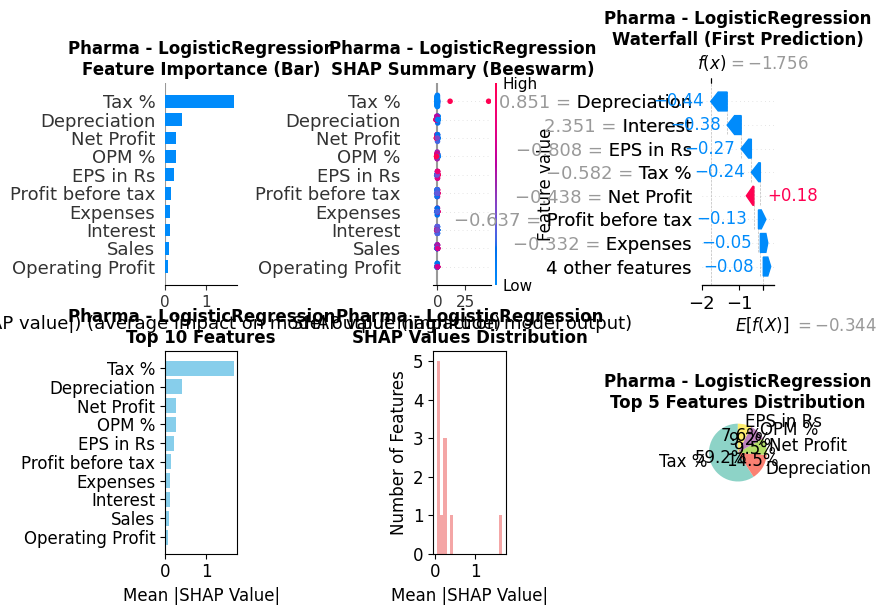

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_Pharma_LogisticRegression.png
   ✅ Top 3 features: Tax %, Depreciation, Net Profit
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   📊 Creating SHAP visualizations...


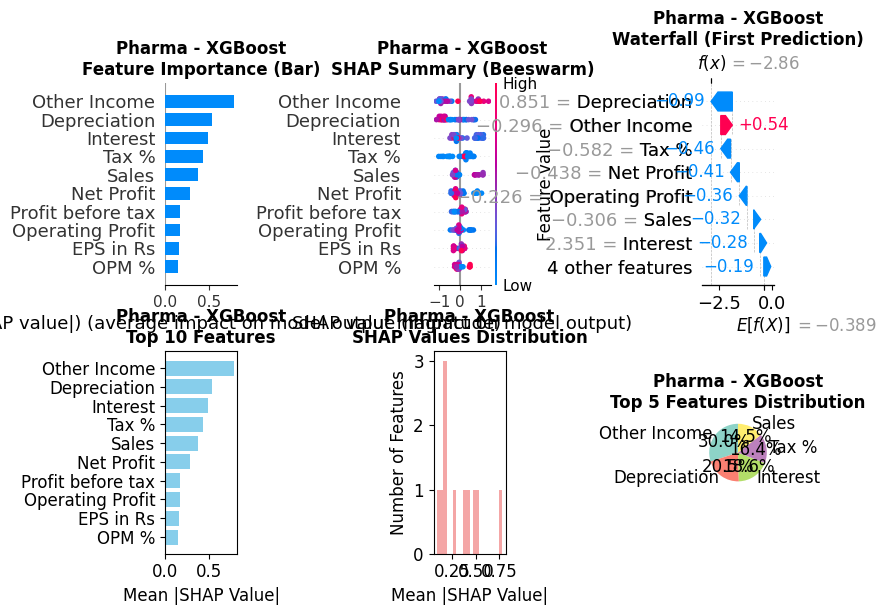

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_Pharma_XGBoost.png
   ✅ Top 3 features: Other Income, Depreciation, Interest

🏢 SHAP Analysis: IT_Technology
--------------------
🔍 SHAP analysis: LogisticRegression...
   📊 Creating SHAP visualizations...


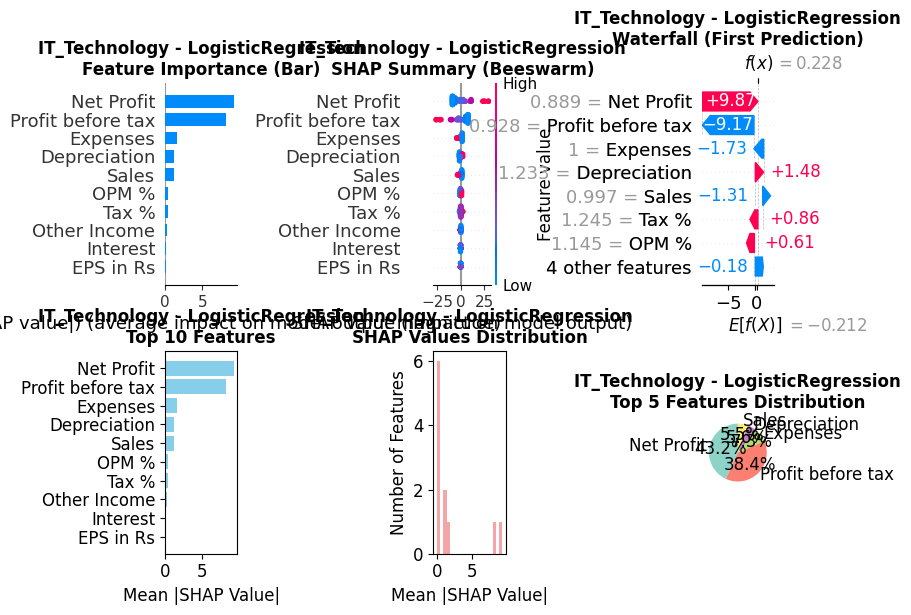

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_IT_Technology_LogisticRegression.png
   ✅ Top 3 features: Net Profit, Profit before tax, Expenses
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   📊 Creating SHAP visualizations...


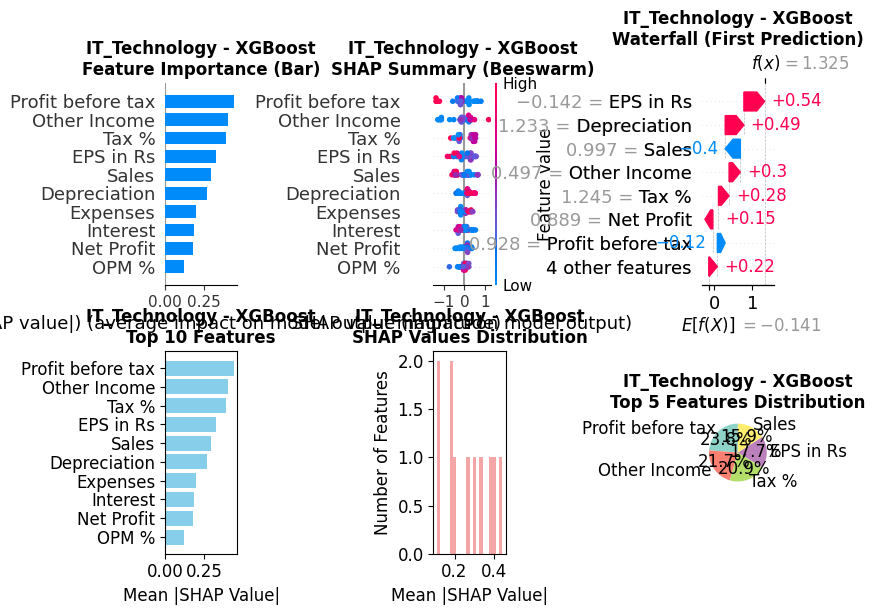

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_IT_Technology_XGBoost.png
   ✅ Top 3 features: Profit before tax, Other Income, Tax %

🏢 SHAP Analysis: Auto
--------------------
🔍 SHAP analysis: LogisticRegression...
   📊 Creating SHAP visualizations...


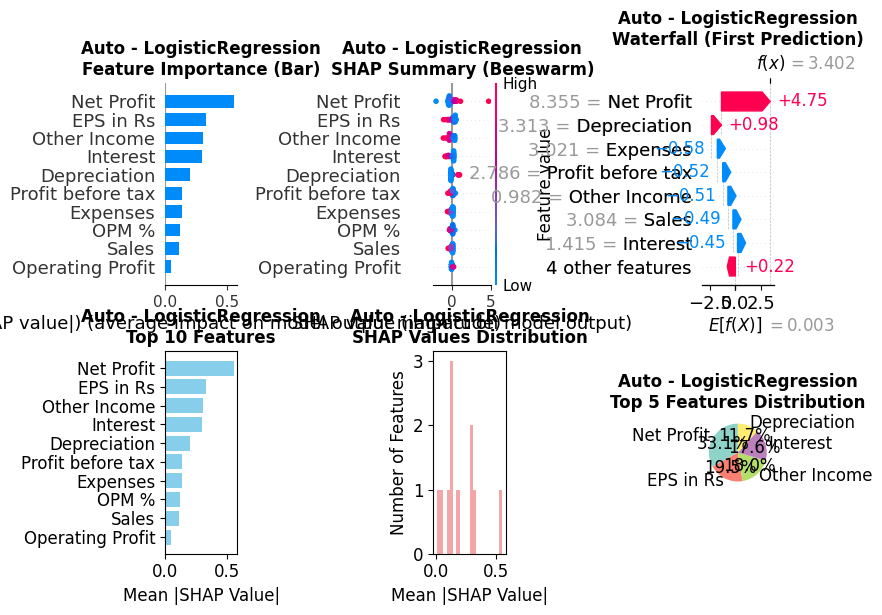

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_Auto_LogisticRegression.png
   ✅ Top 3 features: Net Profit, EPS in Rs, Other Income
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   📊 Creating SHAP visualizations...


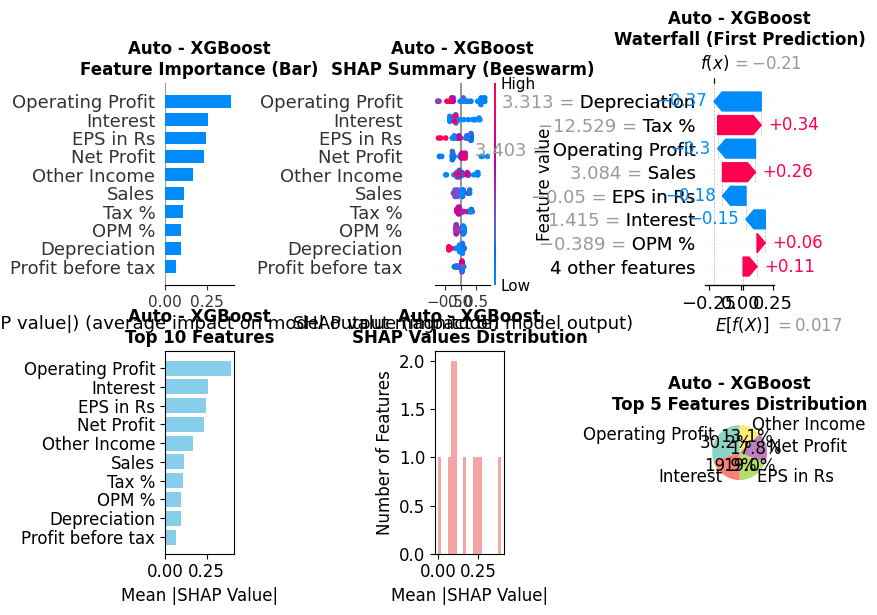

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_Auto_XGBoost.png
   ✅ Top 3 features: Operating Profit, Interest, EPS in Rs

🏢 SHAP Analysis: BFSI
--------------------
🔍 SHAP analysis: LogisticRegression...
   📊 Creating SHAP visualizations...
   ⚠️  Visualization creation failed: cannot convert float NaN to integer
   ✅ Top 3 features: Expenses, Other Income, Interest
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   📊 Creating SHAP visualizations...


ValueError: need at least one array to concatenate

<Figure size 800x550 with 9 Axes>

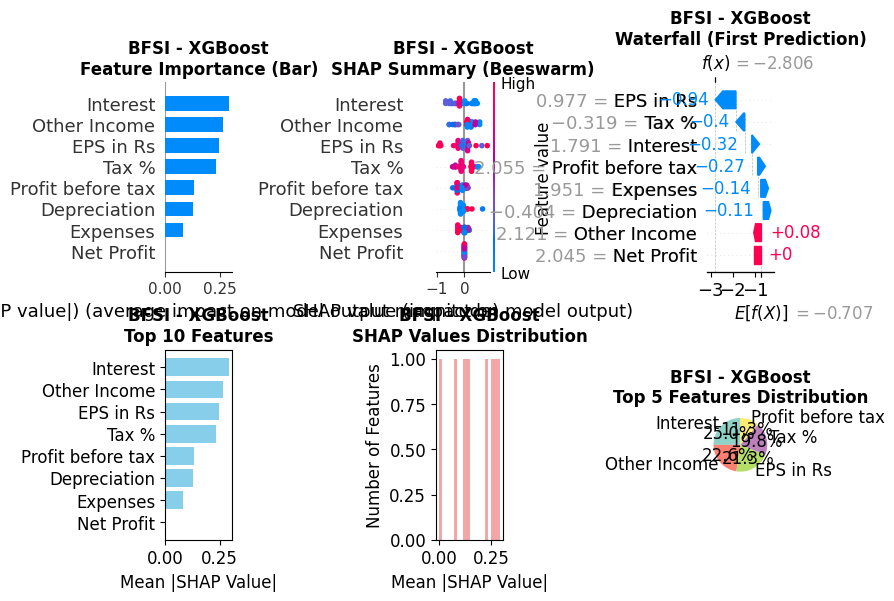

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_BFSI_XGBoost.png
   ✅ Top 3 features: Interest, Other Income, EPS in Rs

🏢 SHAP Analysis: FMCG
--------------------
🔍 SHAP analysis: LogisticRegression...
   📊 Creating SHAP visualizations...


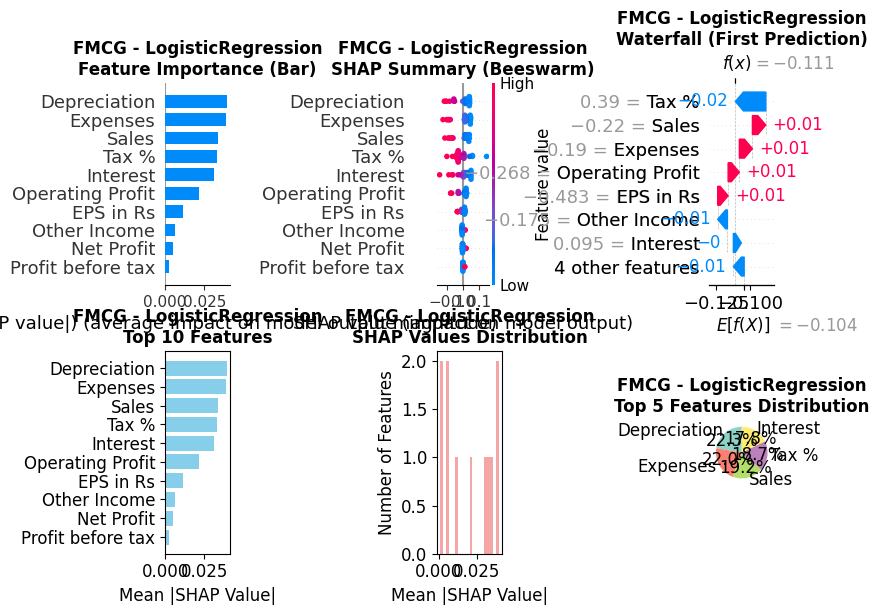

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_FMCG_LogisticRegression.png
   ✅ Top 3 features: Depreciation, Expenses, Sales
🔍 SHAP analysis: RandomForest...
   ⚠️  SHAP analysis failed: Per-column arrays must each be 1-dimensional
🔍 SHAP analysis: XGBoost...
   📊 Creating SHAP visualizations...


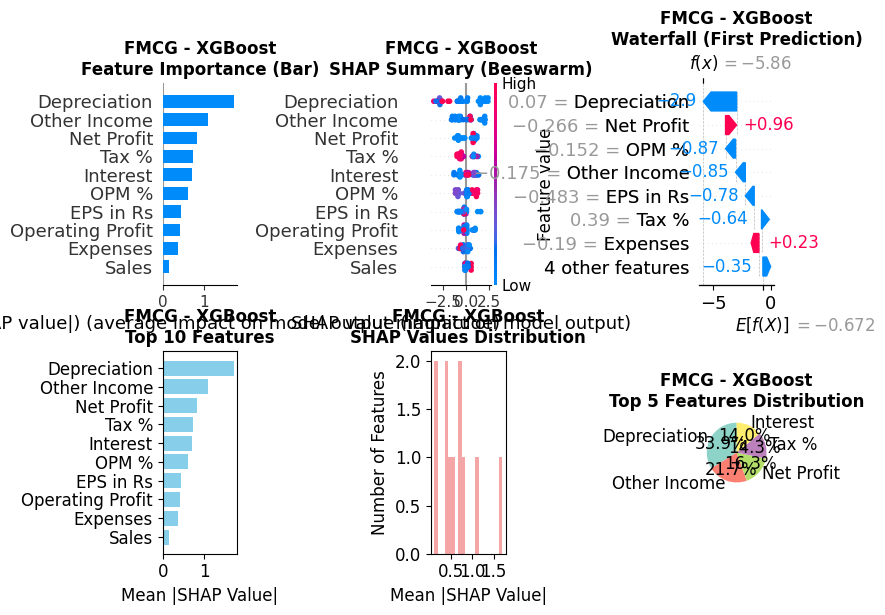

   ✅ Visualizations saved: rq3_analysis_results/shap_analysis_FMCG_XGBoost.png
   ✅ Top 3 features: Depreciation, Other Income, Net Profit


AttributeError: 'list' object has no attribute 'groupby'

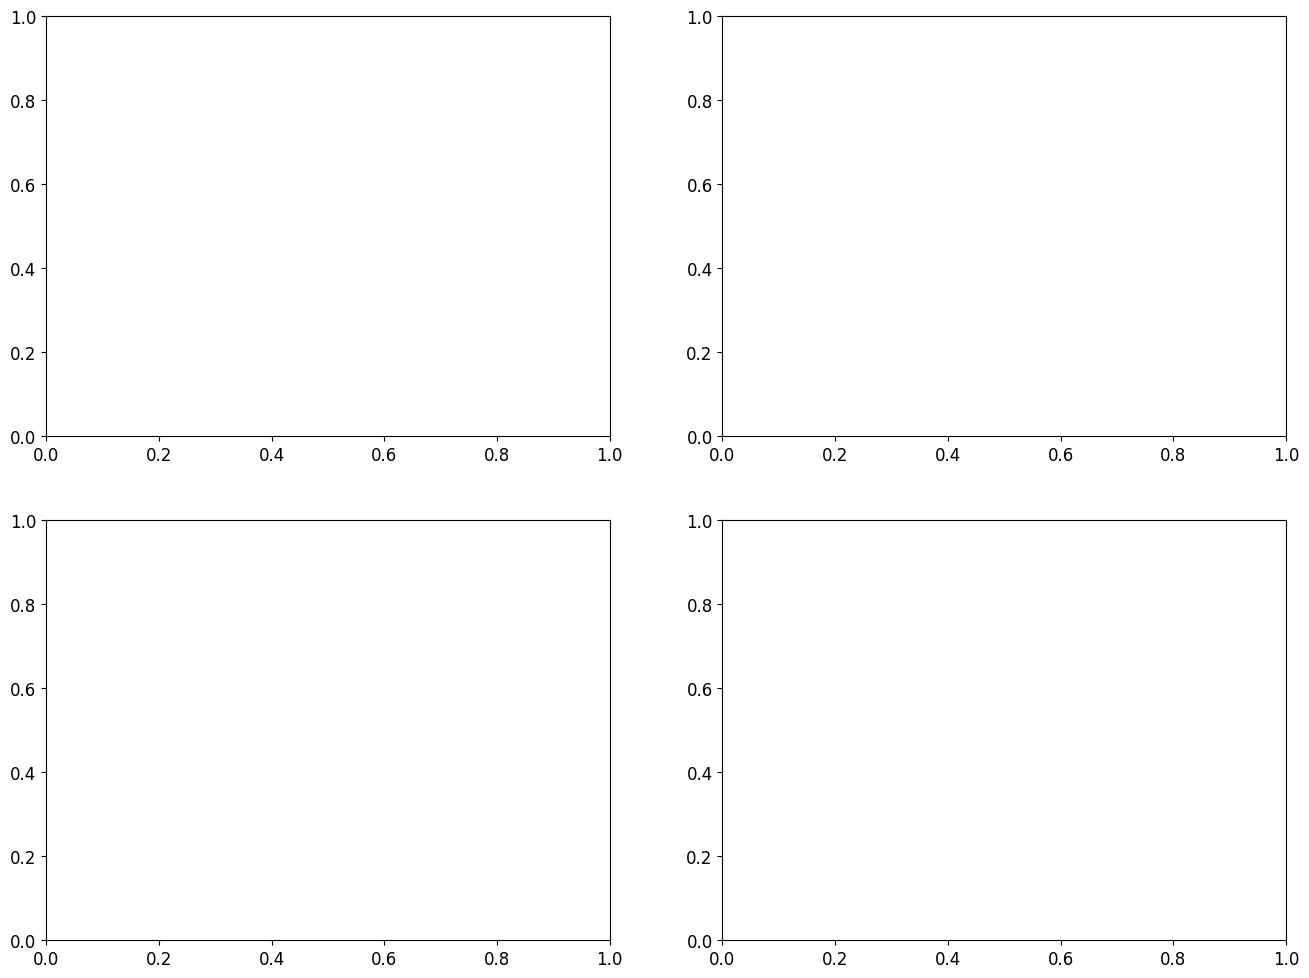

In [60]:
# Cell 7: SHAP Analysis for Feature Importance with Visualizations
print("🔍 SHAP ANALYSIS FOR FEATURE IMPORTANCE")
print("=" * 38)

# Initialize SHAP results storage
shap_results = {}
shap_summary_data = []

# Function to perform SHAP analysis
def perform_shap_analysis(model, X_train, X_test, feature_names, model_name, sector_name):
    """Perform SHAP analysis for model interpretability"""
    
    try:
        # Get the actual model from pipeline
        if hasattr(model, 'named_steps'):
            actual_model = model.named_steps['model']
            # Transform features using the scaler
            X_train_scaled = model.named_steps['scaler'].transform(X_train)
            X_test_scaled = model.named_steps['scaler'].transform(X_test)
        else:
            actual_model = model
            X_train_scaled = X_train
            X_test_scaled = X_test
        
        # Choose appropriate explainer based on model type
        if model_name == 'LogisticRegression':
            explainer = shap.LinearExplainer(actual_model, X_train_scaled)
            shap_values = explainer.shap_values(X_test_scaled)
        elif model_name == 'RandomForest':
            explainer = shap.TreeExplainer(actual_model)
            shap_values = explainer.shap_values(X_test_scaled)
            # For binary classification, take positive class
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        elif model_name == 'XGBoost':
            explainer = shap.TreeExplainer(actual_model)
            shap_values = explainer.shap_values(X_test_scaled)
        else:
            # Fallback to KernelExplainer for other models
            explainer = shap.KernelExplainer(actual_model.predict_proba, X_train_scaled[:100])
            shap_values = explainer.shap_values(X_test_scaled[:50])
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        
        # Calculate feature importance
        feature_importance = np.abs(shap_values).mean(axis=0)
        
        # Create feature importance DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'SHAP_Importance': feature_importance
        }).sort_values('SHAP_Importance', ascending=False)
        
        return {
            'explainer': explainer,
            'shap_values': shap_values,
            'feature_importance': importance_df,
            'X_test_scaled': X_test_scaled,
            'feature_names': feature_names
        }
        
    except Exception as e:
        print(f"   ⚠️  SHAP analysis failed: {str(e)}")
        return None

# Function to create SHAP visualizations
def create_shap_visualizations(shap_results, sector_name, model_name, save_dir):
    """Create comprehensive SHAP visualizations"""
    
    try:
        shap_values = shap_results['shap_values']
        X_test_scaled = shap_results['X_test_scaled']
        feature_names = shap_results['feature_names']
        
        # Create figure with subplots
        fig = plt.figure(figsize=(20, 15))
        
        # 1. Summary Plot (Bar)
        plt.subplot(2, 3, 1)
        shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, 
                         plot_type="bar", show=False, max_display=10)
        plt.title(f'{sector_name} - {model_name}\nFeature Importance (Bar)', fontsize=12, fontweight='bold')
        
        # 2. Summary Plot (Beeswarm)
        plt.subplot(2, 3, 2)
        shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, 
                         show=False, max_display=10)
        plt.title(f'{sector_name} - {model_name}\nSHAP Summary (Beeswarm)', fontsize=12, fontweight='bold')
        
        # 3. Waterfall plot for first prediction
        plt.subplot(2, 3, 3)
        if len(shap_values) > 0:
            shap.waterfall_plot(shap.Explanation(values=shap_values[0], 
                                               base_values=shap_results['explainer'].expected_value,
                                               data=X_test_scaled[0],
                                               feature_names=feature_names), 
                               show=False, max_display=8)
        plt.title(f'{sector_name} - {model_name}\nWaterfall (First Prediction)', fontsize=12, fontweight='bold')
        
        # 4. Feature Importance Bar Chart (Custom)
        plt.subplot(2, 3, 4)
        top_features = shap_results['feature_importance'].head(10)
        plt.barh(range(len(top_features)), top_features['SHAP_Importance'], color='skyblue')
        plt.yticks(range(len(top_features)), top_features['Feature'])
        plt.xlabel('Mean |SHAP Value|')
        plt.title(f'{sector_name} - {model_name}\nTop 10 Features', fontsize=12, fontweight='bold')
        plt.gca().invert_yaxis()
        
        # 5. SHAP Values Distribution
        plt.subplot(2, 3, 5)
        shap_abs_mean = np.abs(shap_values).mean(axis=0)
        plt.hist(shap_abs_mean, bins=20, alpha=0.7, color='lightcoral')
        plt.xlabel('Mean |SHAP Value|')
        plt.ylabel('Number of Features')
        plt.title(f'{sector_name} - {model_name}\nSHAP Values Distribution', fontsize=12, fontweight='bold')
        
        # 6. Top Features Comparison
        plt.subplot(2, 3, 6)
        top_5_features = shap_results['feature_importance'].head(5)
        colors = plt.cm.Set3(np.linspace(0, 1, len(top_5_features)))
        plt.pie(top_5_features['SHAP_Importance'], labels=top_5_features['Feature'], 
                autopct='%1.1f%%', colors=colors, startangle=90)
        plt.title(f'{sector_name} - {model_name}\nTop 5 Features Distribution', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        
        # Save the plot
        filename = f'{save_dir}/shap_analysis_{sector_name}_{model_name}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        return filename
        
    except Exception as e:
        print(f"   ⚠️  Visualization creation failed: {str(e)}")
        return None

print("\n🔬 Performing SHAP analysis for each model-sector combination...")

# Process each sector and model
for sector_name, sector_info in sector_data.items():
    if sector_name not in best_models or len(best_models[sector_name]) == 0:
        continue
        
    print(f"\n🏢 SHAP Analysis: {sector_name}")
    print("-" * 20)
    
    # Prepare data
    df = sector_info['data']
    predictors = sector_info['predictors']
    target_col = sector_info['target']
    
    X = df[predictors].copy()
    y = df[target_col].copy()
    
    # Ensure binary target
    if y.dtype == 'object' or len(y.unique()) > 2:
        y = (y == 1).astype(int)
    
    # Final data cleaning
    X = X.fillna(X.median())
    
    # Train-test split (same as evaluation)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Analyze each model
    sector_shap_results = {}
    
    for model_name, model in best_models[sector_name].items():
        print(f"🔍 SHAP analysis: {model_name}...")
        
        # Perform SHAP analysis
        shap_result = perform_shap_analysis(
            model, X_train, X_test, predictors, model_name, sector_name
        )
        
        if shap_result is not None:
            sector_shap_results[model_name] = shap_result
            
            # Create visualizations
            print(f"   📊 Creating SHAP visualizations...")
            viz_file = create_shap_visualizations(shap_result, sector_name, model_name, OUTPUT_DIR)
            if viz_file:
                print(f"   ✅ Visualizations saved: {viz_file}")
            
            # Store summary data
            top_features = shap_result['feature_importance'].head(5)
            for idx, (_, row) in enumerate(top_features.iterrows()):
                shap_summary_data.append({
                    'Sector': sector_name,
                    'Model': model_name,
                    'Feature_Rank': idx + 1,
                    'Feature_Name': row['Feature'],
                    'SHAP_Importance': row['SHAP_Importance']
                })
            
            print(f"   ✅ Top 3 features: {', '.join(top_features['Feature'].head(3).tolist())}")
        
    # Store sector results
    if sector_shap_results:
        shap_results[sector_name] = sector_shap_results

# Create overall SHAP summary visualization
def create_overall_shap_summary(shap_summary_df, save_dir):
    """Create overall SHAP summary visualizations"""
    
    if len(shap_summary_df) == 0:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Overall feature importance ranking
    feature_importance_agg = shap_summary_df.groupby('Feature_Name')['SHAP_Importance'].mean().sort_values(ascending=True)
    top_15_features = feature_importance_agg.tail(15)
    
    axes[0, 0].barh(range(len(top_15_features)), top_15_features.values, color='skyblue')
    axes[0, 0].set_yticks(range(len(top_15_features)))
    axes[0, 0].set_yticklabels(top_15_features.index, fontsize=10)
    axes[0, 0].set_xlabel('Mean SHAP Importance')
    axes[0, 0].set_title('Top 15 Features - Overall Importance', fontweight='bold')
    
    # 2. Sector-wise feature importance heatmap
    pivot_data = shap_summary_df[shap_summary_df['Feature_Rank'] <= 5].pivot_table(
        values='SHAP_Importance', index='Feature_Name', columns='Sector', aggfunc='mean'
    ).fillna(0)
    
    if not pivot_data.empty:
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0, 1])
        axes[0, 1].set_title('Feature Importance by Sector (Top 5)', fontweight='bold')
        axes[0, 1].set_xlabel('Sector')
        axes[0, 1].set_ylabel('Feature')
    
    # 3. Model-wise comparison
    model_comparison = shap_summary_df.groupby(['Model', 'Feature_Name'])['SHAP_Importance'].mean().reset_index()
    model_avg = model_comparison.groupby('Model')['SHAP_Importance'].mean().sort_values(ascending=False)
    
    axes[1, 0].bar(model_avg.index, model_avg.values, color=['lightcoral', 'lightgreen', 'lightblue'])
    axes[1, 0].set_xlabel('Model')
    axes[1, 0].set_ylabel('Average SHAP Importance')
    axes[1, 0].set_title('Average Feature Importance by Model', fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Feature frequency across models
    feature_frequency = shap_summary_df[shap_summary_df['Feature_Rank'] <= 3]['Feature_Name'].value_counts().head(10)
    
    axes[1, 1].barh(range(len(feature_frequency)), feature_frequency.values, color='gold')
    axes[1, 1].set_yticks(range(len(feature_frequency)))
    axes[1, 1].set_yticklabels(feature_frequency.index, fontsize=10)
    axes[1, 1].set_xlabel('Count')
    axes[1, 1].set_title('Top 10 Features Across Models', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Call the overall summary visualization function
create_overall_shap_summary(shap_summary_data, OUTPUT_DIR)

In [62]:
axes[1, 1].set_xlabel('Frequency in Top 3')
axes[1, 1].set_title('Most Frequent Top-3 Features', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{save_dir}/overall_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Create SHAP summary DataFrame
shap_summary_df = pd.DataFrame(shap_summary_data)

print(f"\n🎉 SHAP ANALYSIS COMPLETE!")
print("=" * 25)

if len(shap_summary_df) > 0:
    print(f"📊 SHAP analyses completed: {len(shap_results)} sectors")
    
    # Create overall summary visualization
    print("\n📊 Creating overall SHAP summary visualization...")
    create_overall_shap_summary(shap_summary_df, OUTPUT_DIR)
    print("✅ Overall SHAP summary saved")
    
    # Overall feature importance ranking
    print(f"\n🏆 OVERALL FEATURE IMPORTANCE RANKING:")
    print("-" * 36)
    
    # Aggregate feature importance across all models and sectors
    feature_importance_agg = shap_summary_df.groupby('Feature_Name')['SHAP_Importance'].agg([
        'mean', 'max', 'count'
    ]).round(4)
    feature_importance_agg = feature_importance_agg.sort_values('mean', ascending=False)
    feature_importance_agg.columns = ['Mean_Importance', 'Max_Importance', 'Appearances']
    
    print("Top 10 Most Important Features (across all sectors):")
    top_10_features = feature_importance_agg.head(10)
    for idx, (feature, row) in enumerate(top_10_features.iterrows(), 1):
        print(f"{idx:2d}. {feature:20s}: Mean={row['Mean_Importance']:.4f}, Max={row['Max_Importance']:.4f} ({int(row['Appearances'])} models)")
    
    # Sector-specific feature importance
    print(f"\n🏢 SECTOR-SPECIFIC TOP FEATURES:")
    print("-" * 31)
    
    for sector in shap_summary_df['Sector'].unique():
        sector_features = shap_summary_df[
            (shap_summary_df['Sector'] == sector) & 
            (shap_summary_df['Feature_Rank'] == 1)
        ]
        
        if len(sector_features) > 0:
            print(f"\n{sector}:")
            for _, row in sector_features.iterrows():
                print(f"  {row['Model']:18s}: {row['Feature_Name']} ({row['SHAP_Importance']:.4f})")
    
    # Model-wise feature consistency analysis
    print(f"\n🤖 MODEL-WISE FEATURE CONSISTENCY:")
    print("-" * 32)
    
    for model in shap_summary_df['Model'].unique():
        model_features = shap_summary_df[
            (shap_summary_df['Model'] == model) & 
            (shap_summary_df['Feature_Rank'] <= 3)
        ]['Feature_Name'].value_counts()
        
        print(f"\n{model}:")
        print(f"  Most consistent top-3 features:")
        for feature, count in model_features.head(5).items():
            print(f"    {feature}: appears in {count} sectors")
    
    # Save SHAP results
    shap_summary_df.to_csv(f'{OUTPUT_DIR}/shap_feature_importance.csv', index=False)
    feature_importance_agg.to_csv(f'{OUTPUT_DIR}/aggregated_feature_importance.csv')
    
    print(f"\n💾 SHAP results saved to {OUTPUT_DIR}/")
    print("   📁 Individual model visualizations: shap_analysis_[sector]_[model].png")
    print("   📁 Overall summary: overall_shap_summary.png")
    print("   📁 Data files: shap_feature_importance.csv, aggregated_feature_importance.csv")
    
else:
    print("⚠️  No SHAP results to analyze")

print(f"\n🔄 Next: Permutation importance analysis...")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed